<a href="https://colab.research.google.com/github/sushil-97/Walmart---Confidence-Interval/blob/main/Walmart_Confidence_interval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Upload csv file

In [ ]:
import pandas as pd
from google.colab import files

In [ ]:
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Assuming a single CSV file is uploaded, otherwise, you might need to select one
  df = pd.read_csv(fn)

display(df.head())

Saving walmart_data.csv to walmart_data.csv
User uploaded file "walmart_data.csv" with length 23027994 bytes


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
df.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


1. Detect Null values & Outliers (using boxplot, “describe” method by checking the difference between mean and median, isnull etc.)

In [ ]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [ ]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0



### Value Counts and Unique Attributes

In [ ]:
print('\nNumber of unique attributes for each column:')
display(df.nunique())


Number of unique attributes for each column:


,0
User_ID,5891
Product_ID,3631
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category,20
Purchase,18105


In [ ]:
print('Value counts for categorical columns:')
for col in df.select_dtypes(include='object').columns:
    print(f'\n--- {col} ---')
    display(df[col].value_counts())

Value counts for categorical columns:

--- Product_ID ---


,count
Product_ID,
P00265242,1880
P00025442,1615
P00110742,1612
P00112142,1562
P00057642,1470
...,...
P00325342,1
P00312542,1
P00008942,1



--- Gender ---


,count
Gender,
M,414259
F,135809



--- Age ---


,count
Age,
26-35,219587
36-45,110013
18-25,99660
46-50,45701
51-55,38501
55+,21504
0-17,15102



--- City_Category ---


,count
City_Category,
B,231173
C,171175
A,147720



--- Stay_In_Current_City_Years ---


,count
Stay_In_Current_City_Years,
1,193821
2,101838
3,95285
4+,84726
0,74398


#### Univariate Analysis: Counts of Categorical Variables (Countplots)


/tmp/ipykernel_6270/3308076213.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
/tmp/ipykernel_6270/3308076213.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
/tmp/ipykernel_6270/3308076213.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
/tmp/ipykernel_6270/3308076213.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `leg

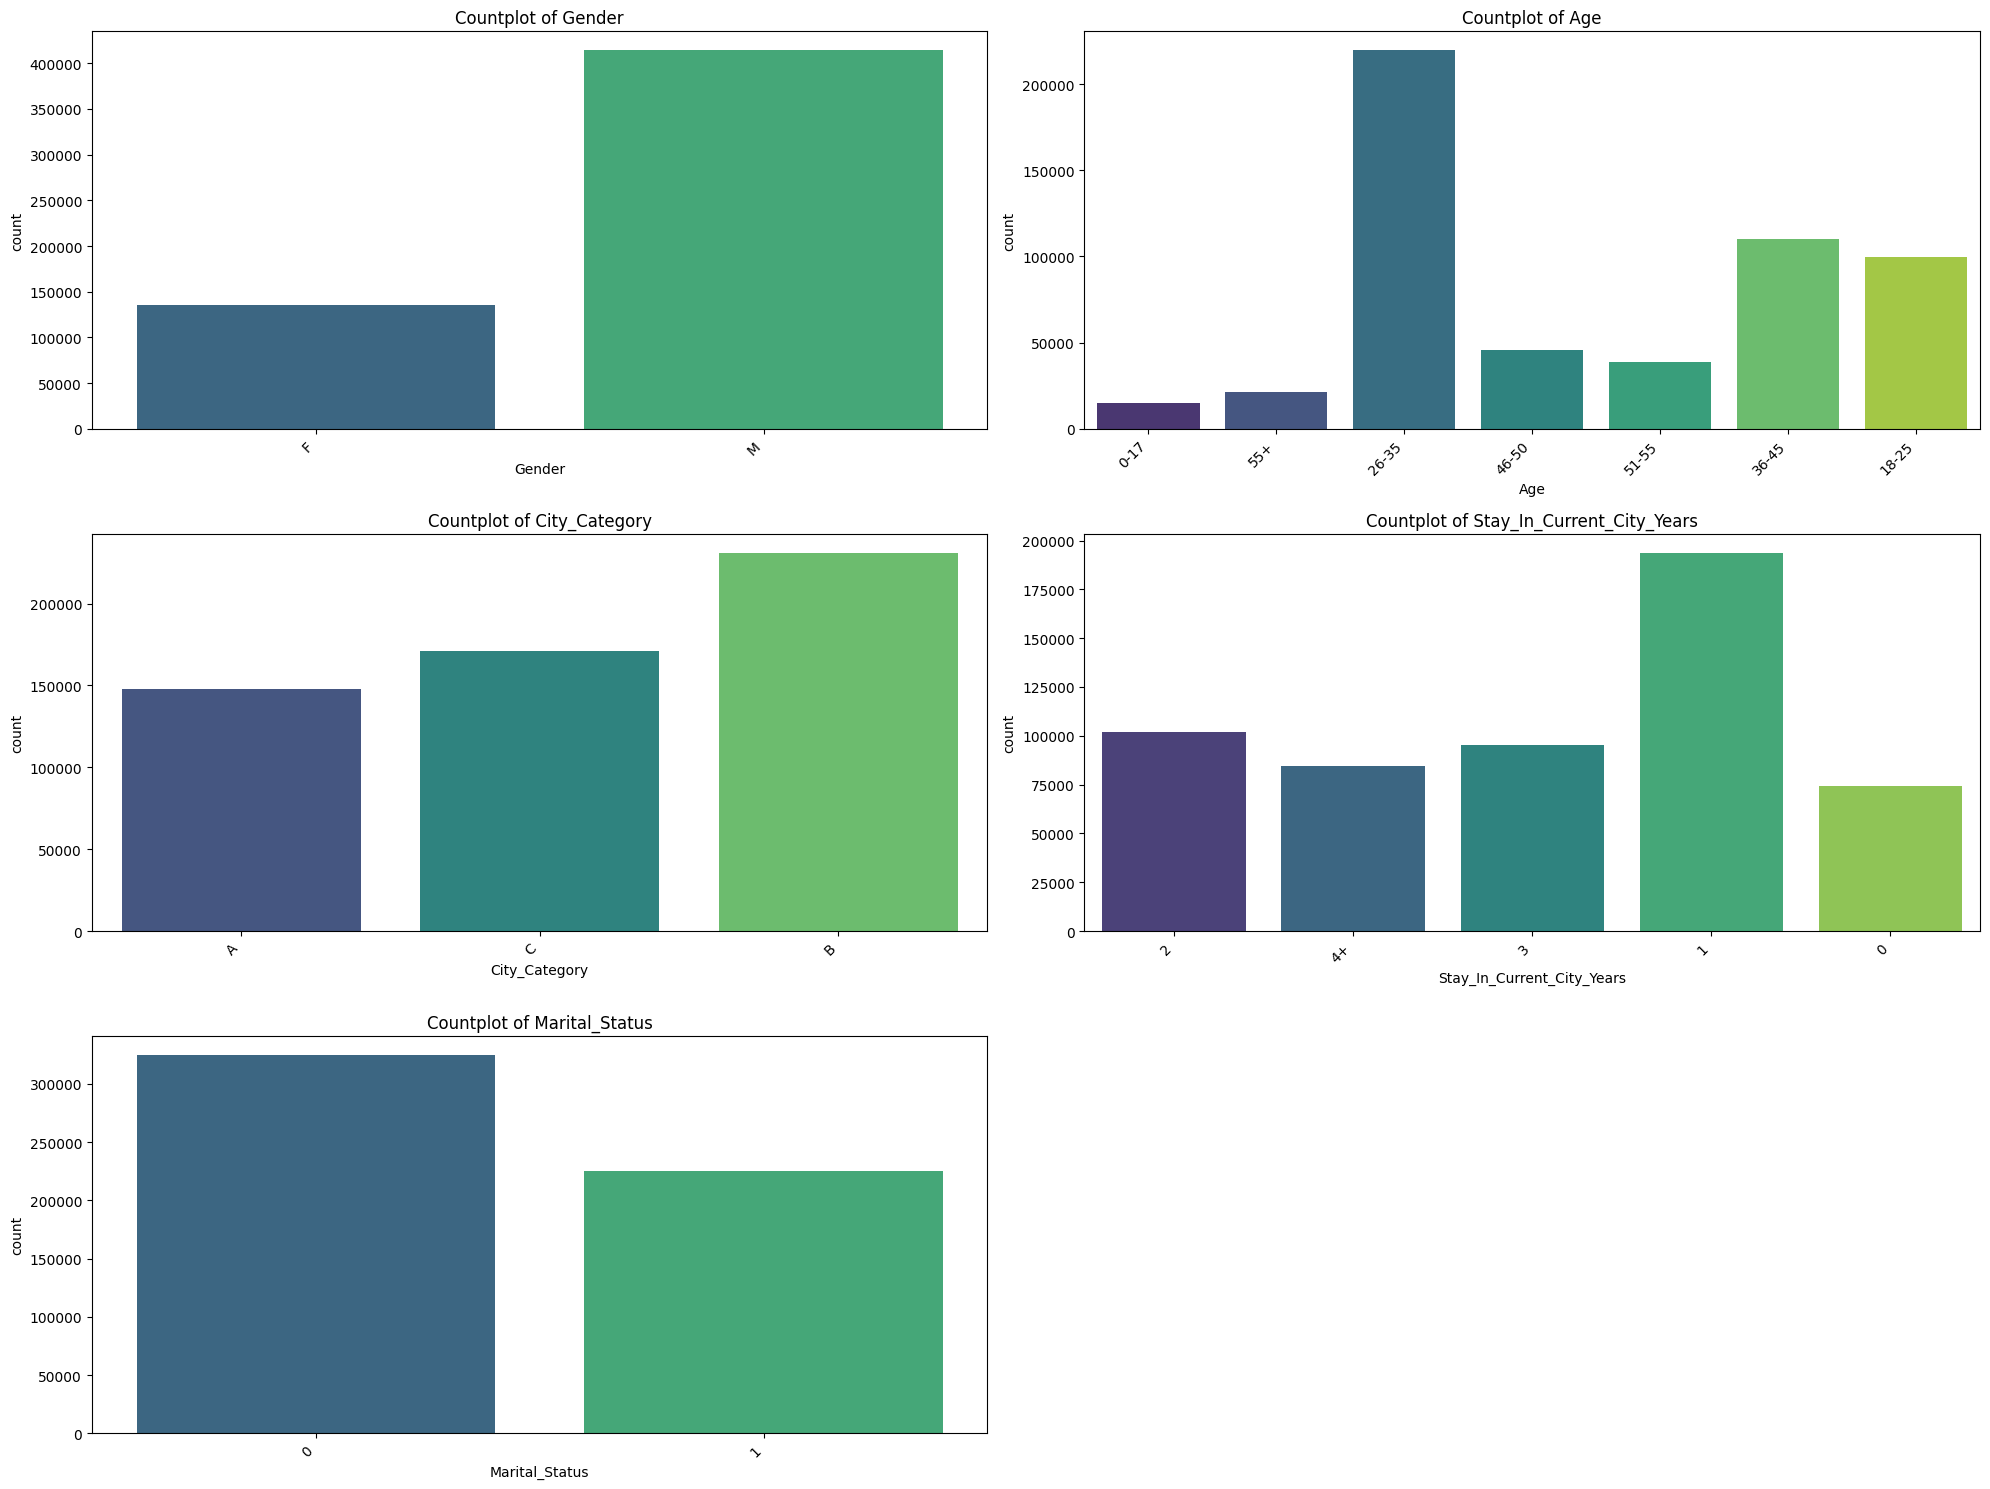

In [ ]:
categorical_cols = ['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status']

plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 2, i + 1)
    sns.countplot(x=col, data=df, palette='viridis')
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Bivariate Analysis: Numerical Variable Distribution across Categorical Groups (Boxplots)

/tmp/ipykernel_6270/3514841625.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Purchase', data=df, palette='magma')
/tmp/ipykernel_6270/3514841625.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Purchase', data=df, palette='magma')
/tmp/ipykernel_6270/3514841625.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Purchase', data=df, palette='magma')
/tmp/ipykernel_6270/3514841625.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` 

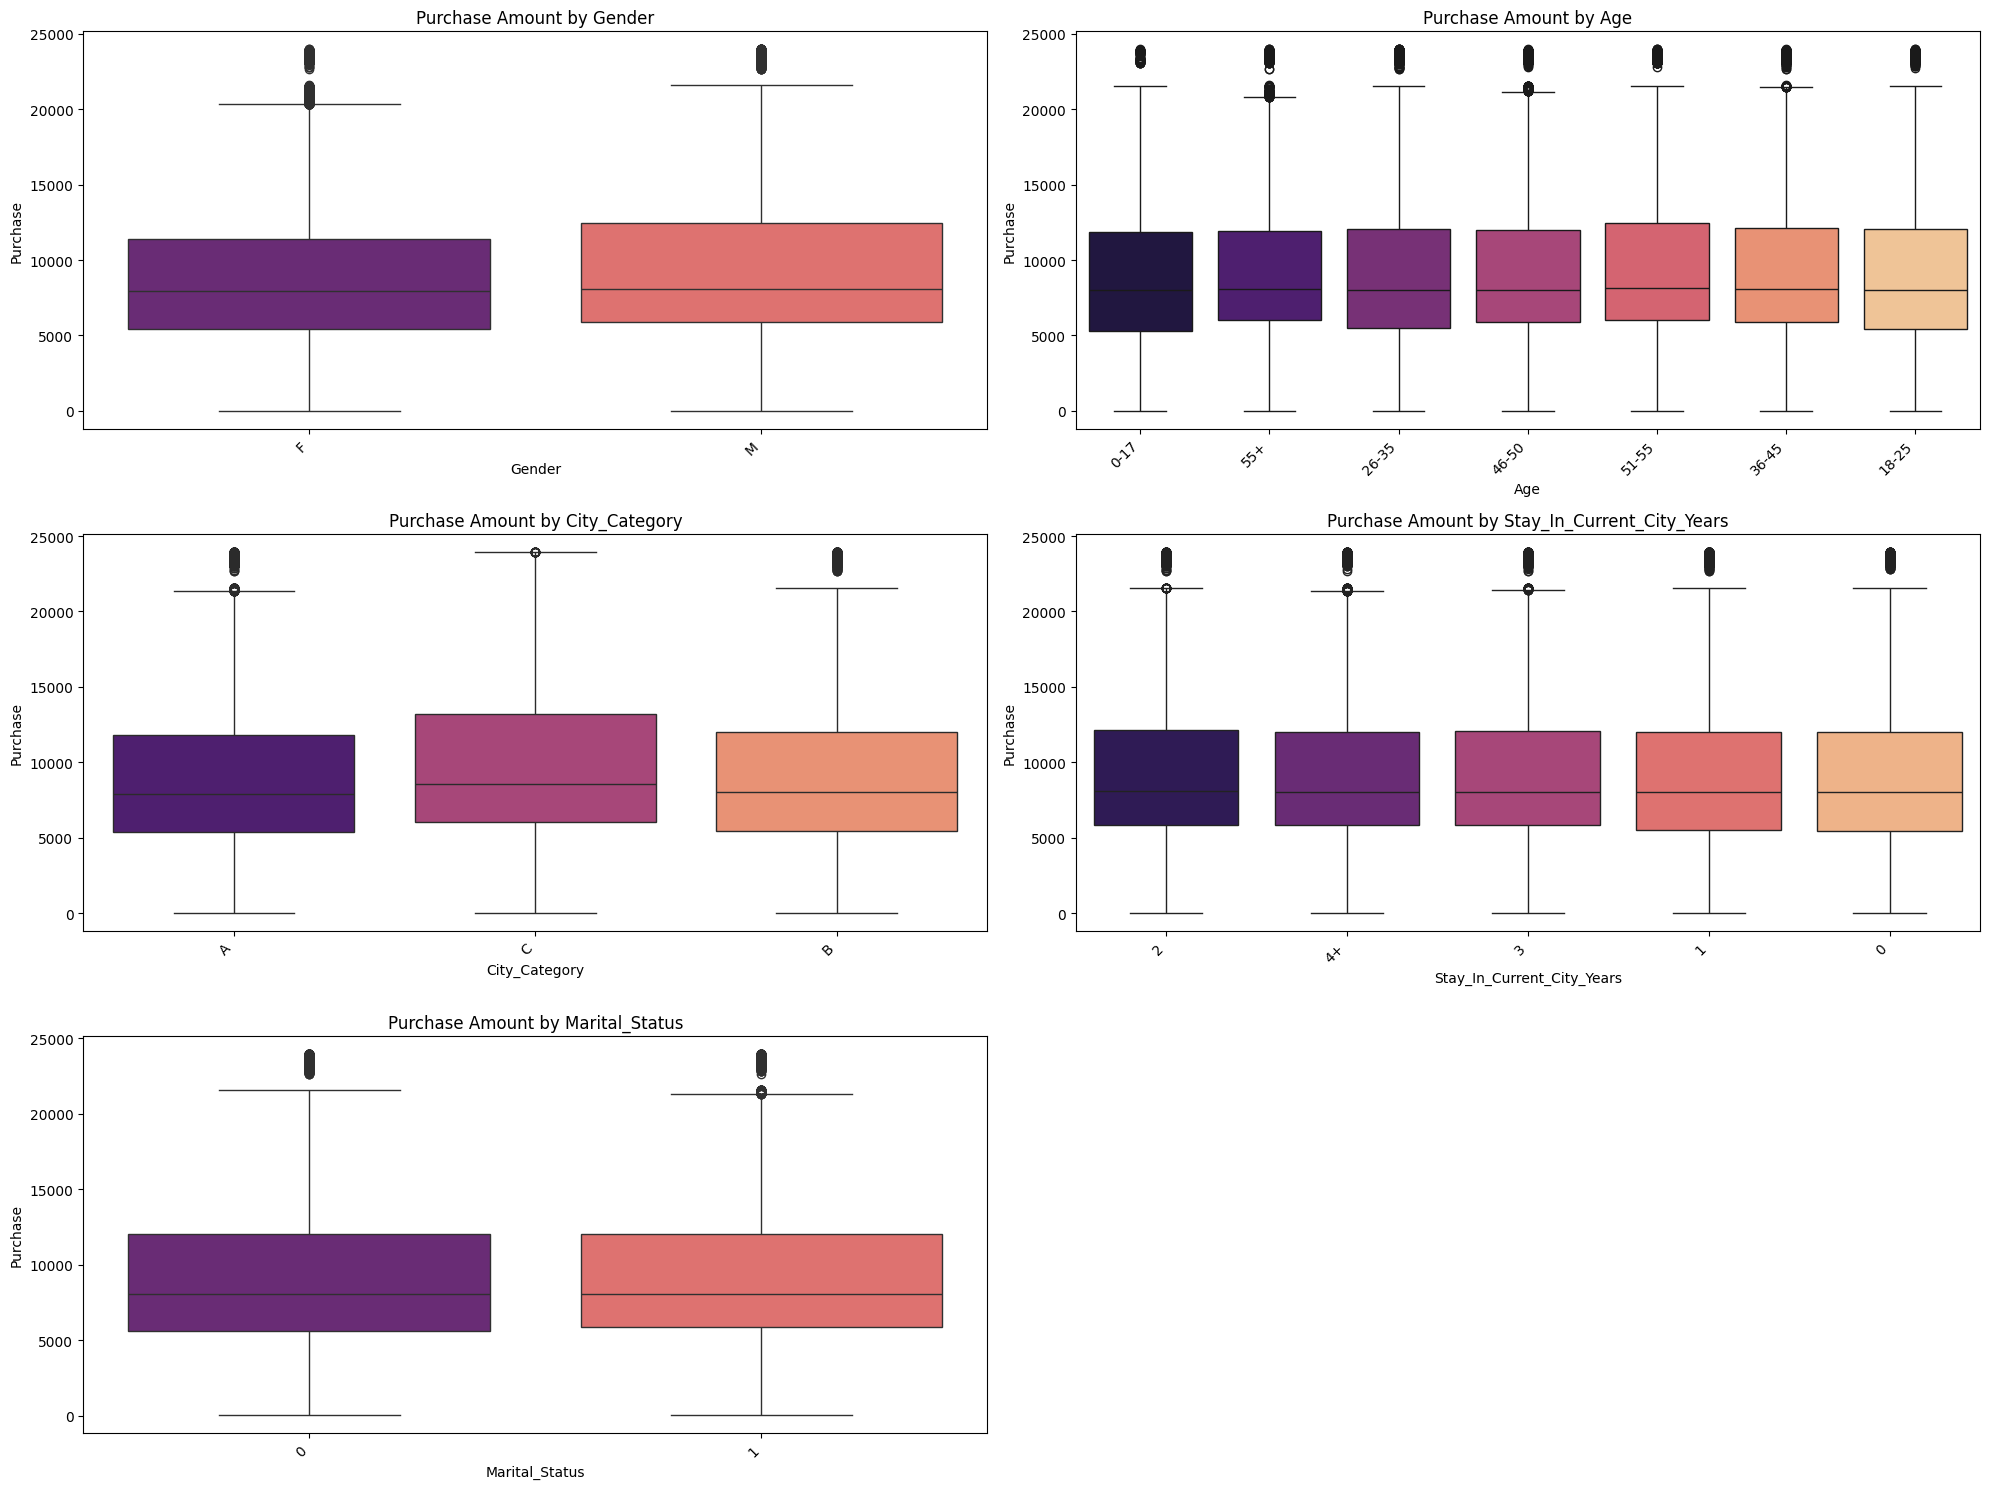

In [ ]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x=col, y='Purchase', data=df, palette='magma')
    plt.title(f'Purchase Amount by {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Bivariate Analysis: Correlation (Heatmap and Pairplot)

In [ ]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


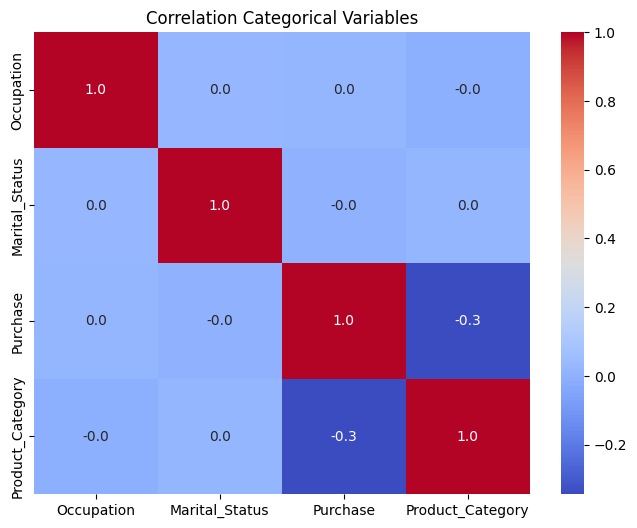

In [ ]:
numerical_corr = ['Occupation', 'Marital_Status',  'Purchase', 'Product_Category']
correlation = df[numerical_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, cmap='coolwarm', annot=True,fmt=".1f")
plt.title('Correlation Categorical Variables')
plt.show()

### Outlier Detection using Boxplots

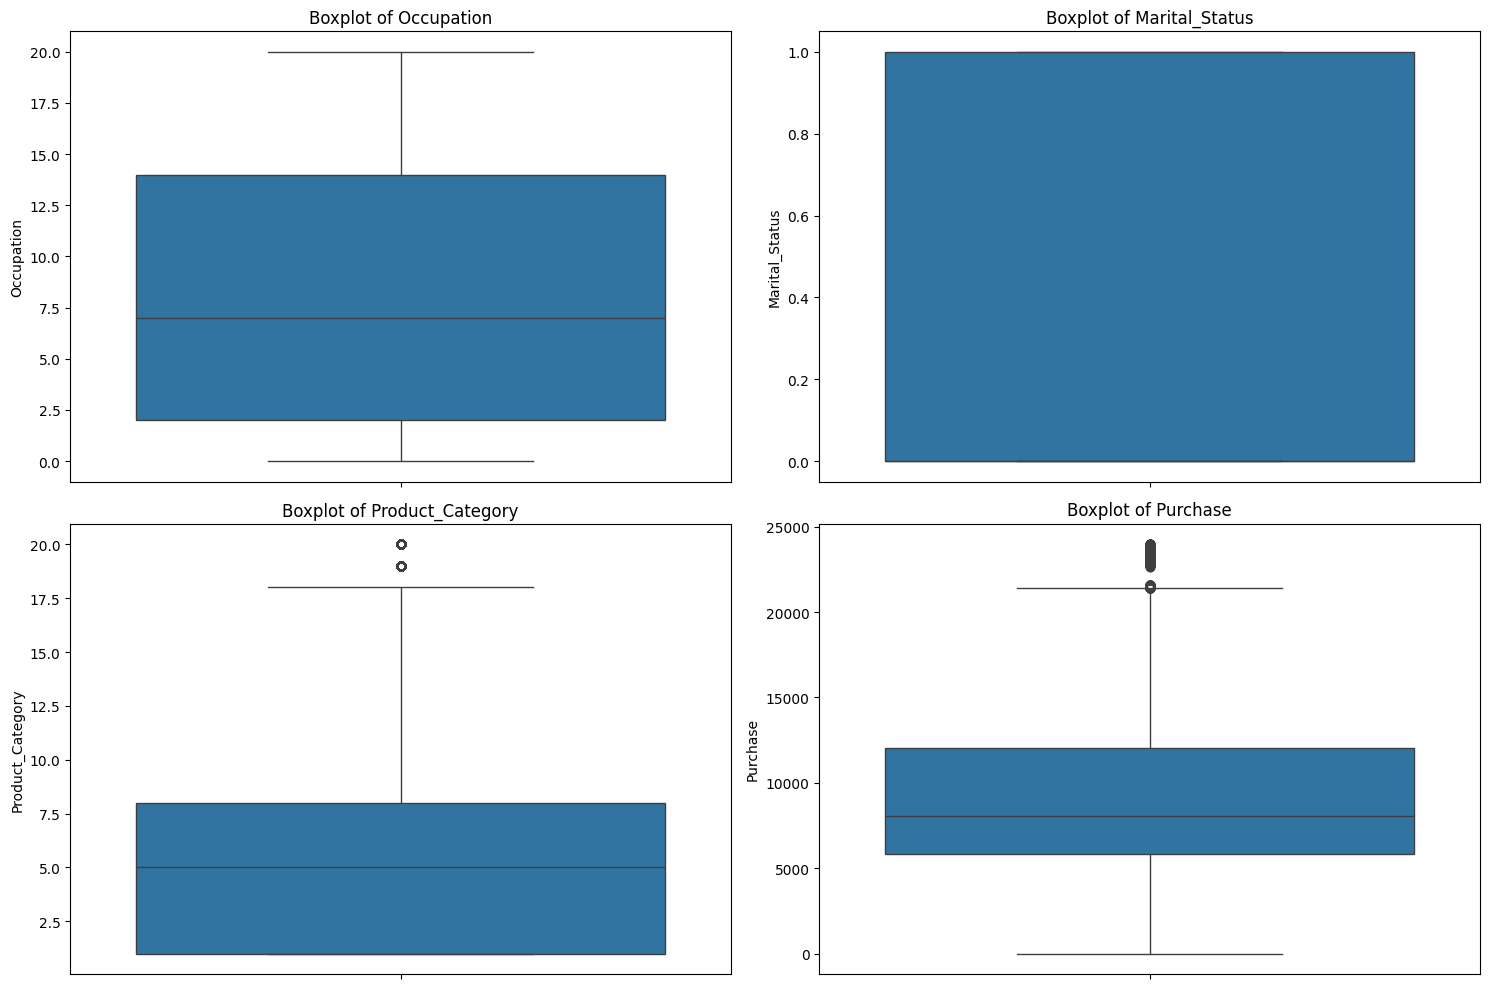

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Occupation', 'Marital_Status', 'Product_Category', 'Purchase']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
  plt.subplot(2, 2, i + 1 )
  sns.boxplot(y=df[col])
  plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

2. Do some data exploration steps like:

a. Tracking the amount spent per transaction of all the 50 million female customers, and all the 50 million male customers, calculate the average, and conclude the results.

b. Inference after computing the average female and male expenses.

c. Use the sample average to find out an interval within which the population average will lie.
Using the sample of female customers you will calculate the interval within which the average spending of 50 million male and female customers may lie.

In [ ]:
"""a. Tracking the amount spent per transaction of all the 50 million female customers,
and all the 50 million male customers, calculate the average, and conclude the results."""

In [ ]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
gender_tranc = df.groupby('Gender')['Purchase'].mean()
print('Average purchase amount by gender:')

gender_tranc

Average purchase amount by gender:


,Purchase
Gender,
F,8734.565765
M,9437.526040


***Based on the current dataset, the average purchase amount for male customers around 9437.53 is higher than that for female customers around 8734.57. This suggests that, on average, male customers tend to spend more per transaction.***

In [ ]:
from scipy.stats import norm

overall_purchases = df['Purchase']

mean_overall_purchase = overall_purchases.mean()
std_overall_purchase = overall_purchases.std()
count_overall_purchase = overall_purchases.count()

# Select the confidence level (C)
CL = 0.95
alpha = 1- CL

# Calculate the Standard Error of the Mean
sample_dist = std_overall_purchase / np.sqrt(count_overall_purchase)

# Calculate the Margin of Error (MOE) using a z-score for a large sample
# For a 95% confidence interval, the z-score is approximately 1.96
z_score = norm.ppf(1-alpha/2)
CI_overall = z_score * sample_dist

# Calculate the Confidence Interval
CI_overall_lower = mean_overall_purchase - CI_overall
CI_overall_upper = mean_overall_purchase + CI_overall


print(f"Sample Mean (Overall): {mean_overall_purchase:.2f}")
print(f"Sample Standard Deviation (Overall): {std_overall_purchase:.2f}")
print(f"Sample Size (Overall): {int(count_overall_purchase)}")
print(f"Standard Error of the Mean (Overall): {sample_dist:.2f}")
print(f"Margin of Error (Overall): {CI_overall:.2f}")
print(f"95% Confidence Interval for Overall Average Spending: ({CI_overall_lower:.2f}, {CI_overall_upper:.2f})")


Sample Mean (Overall): 9263.97
Sample Standard Deviation (Overall): 5023.07
Sample Size (Overall): 550068
Standard Error of the Mean (Overall): 6.77
Margin of Error (Overall): 13.27
95% Confidence Interval for Overall Average Spending: (9250.69, 9277.24)


Explanation : Conclusion on Overall Confidence Interval
Based on the entire sample of transactions, we are 95% confident that the true average spending for the entire population of 50 million male and female customers lies between 9250.69 and 9277.24. This interval provides a statistical estimate of where the population average spending is expected to fall, given our sample data.

Q4 . Use the Central limit theorem to compute the interval. Change the sample size to observe the distribution of the mean of the expenses by female and male customers.

- The interval that you calculated is called Confidence Interval. The width of the interval is mostly decided by the business: Typically 90%, 95%, or 99%. Play around with the width parameter and report the observations.




**# Confidence Interval for Female**

In [ ]:
# Confidence Interval for Female


from scipy.stats import norm

# selection female from gender
female_purchase = df[df['Gender'] == 'F']['Purchase']

mean_female_purchase = female_purchase.mean()
std_female_purchase = female_purchase.std()
count_female_purchase = female_purchase.count()

print(f"Female sample mean: {mean_female_purchase :.2f}")
print(f"Female sample std: {std_female_purchase :.2f}")
print(f"Female sample count: {int(count_female_purchase) :.2f}")


# Calculate the Standard Error of the Mean
female_dist = std_female_purchase / np.sqrt(count_female_purchase)

# set Confidence Levels

Confidence_levels = [0.90, 0.95, 0.99]

for i in Confidence_levels:
  alpha = 1 - i
  z_score_female = norm.ppf(1 - alpha / 2)
  CI_female = z_score_female * female_dist # This is the correct Margin of Error

  CI_female_lower = mean_female_purchase - CI_female
  CI_female_upper = mean_female_purchase + CI_female

  print(f"\n{int(i*100)}% and Confidence interval for lower {CI_female_lower:.2f} and for upper it is {CI_female_upper:.2f}" )
  print(f"Margin of error is {int(i*100)}%: {CI_female:.2f}") # Print CI_female here


Female sample mean: 8734.57
Female sample std: 4767.23
Female sample count: 135809.00

90% and Confidence interval for lower 8713.29 and for upper it is 8755.84
Margin of error is 90%: 21.28

95% and Confidence interval for lower 8709.21 and for upper it is 8759.92
Margin of error is 95%: 25.35

99% and Confidence interval for lower 8701.24 and for upper it is 8767.89
Margin of error is 99%: 33.32


**# Confidence Interval for Male**

In [ ]:
# Confidence Interval for Male

from scipy.stats import norm

# selection female from gender
male_purchase = df[df['Gender'] == 'M']['Purchase']

mean_male_purchase = male_purchase.mean()
std_male_purchase = male_purchase.std()
count_male_purchase = male_purchase.count()

print(f"male sample mean: {mean_male_purchase :.2f}")
print(f"male sample std: {std_male_purchase :.2f}")
print(f"male sample count: {int(count_male_purchase) :.2f}")


# Calculate the Standard Error of the Mean
male_dist = std_male_purchase / np.sqrt(count_male_purchase)

# set Confidence Levels

Confidence_levels = (0.90, 0.95, 0.99)

for i in Confidence_levels:
  alpha = 1 - i
  z_score = norm.ppf(1-alpha / 2)
  CI_male = z_score * male_dist

  CI_male_lower = mean_male_purchase - CI_male
  CI_male_upper = mean_male_purchase + CI_male

  print(f"\n{int(i*100)}% and Confidence interval for lower {CI_male_lower:.2f} and for upper it is {CI_male_upper:.2f}" )
  print(f"Margin of error is {i*100}% : {CI_male}")


male sample mean: 9437.53
male sample std: 5092.19
male sample count: 414259.00

90% and Confidence interval for lower 9424.51 and for upper it is 9450.54
Margin of error is 90.0% : 13.013543166777218

95% and Confidence interval for lower 9422.02 and for upper it is 9453.03
Margin of error is 95.0% : 15.50659310969387

99% and Confidence interval for lower 9417.15 and for upper it is 9457.91
Margin of error is 99.0% : 20.379117802785665


## Confidence Interval for Marital Status

In [ ]:
marital_status_tranc = df.groupby('Marital_Status')['Purchase'].mean()
print('Average purchase amount by Marital Status:')
display(marital_status_tranc)

Average purchase amount by Marital Status:


,Purchase
Marital_Status,
0,9265.907619
1,9261.174574


Explanation : We then computed confidence intervals for female and male customers separately, exploring how the width of the interval changes with different confidence levels (90%, 95%, 99%). We observed that a higher confidence level leads to a wider interval.

**Q5. Conclude the results and check if the confidence intervals of average male and female spends are overlapping or not overlapping. How can Walmart leverage this conclusion to make changes or improvements?**

Based on the Confidence Intervals of both female and male the average spending does not overlap with each other.

**Male Customer** -

According to our analysis, we can say that the male customer spend more that the female customer. Walamart can provide high valued items, provide rewards and can promote high purchase by doing analysis on what makes men spend more on (ex- electronic, clothes, food extras,tools, automotive etc), so they should promote them more.

**Female Customer** -

For female, we can provide, check their frequency of purchase and offer them family based product, asthetics items and provide them offers and promote sales. We can also provide personalized and shopping experience.



**Q6. Perform the same activity for Married vs Unmarried and Age
For Age, you can try bins based on life stages: 0-17, 18-25, 26-35, 36-50, 51+ years.**

**Confidence Interval for Marital Status**

In [ ]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
marital_status_tranc = df.groupby('Marital_Status')['Purchase'].mean()
print(f"Average purchase according to marital status : \n {marital_status_tranc}")

Average purchase according to marital status : 
 Marital_Status
0    9265.907619
1    9261.174574
Name: Purchase, dtype: float64


**Confidence Interval for Unmarried Customers (Marital Status = 0)**

In [ ]:
unmarried_purchase = df[df['Marital_Status']==0]['Purchase']

mean_unmarried_purchase = unmarried_purchase.mean()
std_unmarried_purchase = unmarried_purchase.std()
count_unmarried_purchase = unmarried_purchase.count()

print(f"Unmarried sample mean: {mean_unmarried_purchase :.2f}")
print(f"Unmarried sample std: {std_unmarried_purchase :.2f}")
print(f"Unmarried sample count: {int(count_unmarried_purchase) :.0f}")

unmarried_dist = std_unmarried_purchase / np.sqrt(count_unmarried_purchase)

Confidence_levels = [0.90, 0.95, 0.99]

for i in Confidence_levels:
  alpha = 1 - i
  zscore = norm.ppf(1 - alpha/2)
  CI_unmarried = zscore * unmarried_dist

  CI_unmarried_lower = mean_unmarried_purchase - CI_unmarried
  CI_unmarried_upper = mean_unmarried_purchase + CI_unmarried # Corrected line

  print(f"\n{int(i*100)}% Confidence interval for Unmarried: ({CI_unmarried_lower:.2f}, {CI_unmarried_upper:.2f})")
  print(f"Margin of error ({int(i*100)}%): {CI_unmarried:.2f}")

Unmarried sample mean: 9265.91
Unmarried sample std: 5027.35
Unmarried sample count: 324731

90% Confidence interval for Unmarried: (9251.40, 9251.40)
Margin of error (90%): 14.51

95% Confidence interval for Unmarried: (9248.62, 9248.62)
Margin of error (95%): 17.29

99% Confidence interval for Unmarried: (9243.18, 9243.18)
Margin of error (99%): 22.72


**Confidence Interval for Married Customers (Marital Status = 1)**


In [ ]:
married_purchase = df[df['Marital_Status']==1]['Purchase']

mean_married_purchase = married_purchase.mean()
std_married_purchase = married_purchase.std()
count_married_purchase = married_purchase.count()

print(f"Married sample mean: {mean_married_purchase :.2f}")
print(f"Married sample std: {std_married_purchase :.2f}")
print(f"Married sample count: {int(count_married_purchase) :.0f}")

married_dist = std_married_purchase / np.sqrt(count_married_purchase)

Confidence_levels = [0.90, 0.95, 0.99]

for i in Confidence_levels:
  alpha = 1 - i
  zscore = norm.ppf(1 - alpha/2)
  CI_married = zscore * married_dist

  CI_married_lower = mean_married_purchase - CI_married
  CI_married_upper = mean_married_purchase + CI_married

  print(f"\n{int(i*100)}% Confidence interval for Married: ({CI_married_lower:.2f}, {CI_married_upper:.2f})")
  print(f"Margin of error ({int(i*100)}%): {CI_married:.2f}")

Married sample mean: 9261.17
Married sample std: 5016.90
Married sample count: 225337

90% Confidence interval for Married: (9243.79, 9278.56)
Margin of error (90%): 17.38

95% Confidence interval for Married: (9240.46, 9281.89)
Margin of error (95%): 20.71

99% Confidence interval for Married: (9233.95, 9288.40)
Margin of error (99%): 27.22


**Q6 . Give recommendations and action items to Walmart.**




**for Male and Female:**

Based on the Confidence Intervals of both female and male the average spending does not overlap with each other.

Male Customer -

According to our analysis, we can say that the male customer spend more that the female customer. Walamart can provide high valued items, provide rewards and can promote high purchase by doing analysis on what makes men spend more on (ex- electronic, clothes, food extras,tools, automotive etc), so they should promote them more.

Female Customer -

For female, we can provide, check their frequency of purchase and offer them family based product, asthetics items and provide them offers and promote sales. We can also provide personalized and shopping experience.





**for Married and Unmarried :**

If we observed both unmarried and married data, we can see that the there is an overlap between them, it suggests that there is no statistically significant difference. Walmart wont get any significant statistical differenct in the average purchase amount between married and unmarried, so i think walamrt should look for other purchasing behaviour which will help them optimize the purchasing behaviour of their customer like (ex- frequency of visits, preferred product categories, online vs. in-store shopping). If still want to analysis married customer, we can check for there frequency of their product they buy such as home items, this could reveal valuable insight which could help in promotions.